# Sensitivity tutorial: Serpent files

This notebook reads the Serpent multi-group sensitivity files available for
the Jezebel and Godiva benchmarks. It is also written as a lightweight smoke
test: the code cells contain assertions on the reader, energy-grid ordering,
extraction, merging, and collapsing operations.

In [2]:
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib"))

def find_project_root(start: Path | None = None) -> Path:
    """Find the pyNDUS repository root."""
    start = (start or Path.cwd()).resolve()

    for directory in (start, *start.parents):
        if (
            (directory / "setup.py").is_file()
            and (directory / "src" / "pyNDUS").is_dir()
            and (directory / "docs" / "tutorials").is_dir()
        ):
            return directory

    raise FileNotFoundError(
        f"Could not find the pyNDUS repository root starting from {start}"
    )


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "docs" / "tutorials"
assert DATA_ROOT.exists(), f"Tutorial data directory not found: {DATA_ROOT}"

SENS_ROOT = DATA_ROOT / "MG_sensitivities"
COV_ROOT = DATA_ROOT / "MG_covariances"
assert SENS_ROOT.exists(), SENS_ROOT
assert COV_ROOT.exists(), COV_ROOT

In [3]:
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyNDUS import Sensitivity

## Read Jezebel and Godiva

Serpent sensitivity files are read directly with `Sensitivity`. The current
pyNDUS convention stores profiles in ascending energy order.

In [4]:
serpent_files = {
    "jezebel": SENS_ROOT / "serpent" / "jezebel_sens0.m",
    "godiva": SENS_ROOT / "serpent" / "godiva_sens0.m",
}

sens = {name: Sensitivity(path) for name, path in serpent_files.items()}

for name, obj in sens.items():
    assert obj.reader == "serpent"
    assert obj.energy_unit == "MeV"
    assert obj.n_groups == 33
    assert np.all(np.diff(obj.group_structure) > 0.0)
    assert "keff" in obj.responses

summary = pd.DataFrame({
    name: {
        "responses": ", ".join(obj.responses),
        "materials": ", ".join(obj.materials.keys()),
        "nuclides": ", ".join(obj.zais.keys()),
        "n_MTs": obj.n_MTs,
        "n_groups": obj.n_groups,
    }
    for name, obj in sens.items()
}).T
summary

,responses,materials,nuclides,n_MTs,n_groups
jezebel,"keff, beff, leff",total,"Pu-239, Pu-240, Pu-241, Ga-69, Ga-71",55,33
godiva,"keff, beff, leff",total,"U-235, U-238, U-234",55,33


## Extract profiles

The default group order is ascending. The optional descending view is still
available and should be the reverse of the default extraction.

In [5]:
jezebel = sens["jezebel"]
godiva = sens["godiva"]

pu239_fission_avg, pu239_fission_rsd = jezebel.get(resp="keff", mat="total", za="Pu-239", MT=18)
pu239_desc_avg, _ = jezebel.get(resp="keff", mat="total", za="Pu-239", MT=18,
                                group_order="descending",
                                )

u235_capture_avg, u235_capture_rsd = godiva.get(resp="keff", mat="total", za="U-235", MT=102)

assert pu239_fission_avg.shape[-1] == jezebel.n_groups
assert u235_capture_avg.shape[-1] == godiva.n_groups
np.testing.assert_allclose(pu239_desc_avg.reshape(-1), pu239_fission_avg.reshape(-1)[::-1])

pd.DataFrame({
    "E_upper_MeV": jezebel.group_structure[1:],
    "Pu239_MT18_keff": pu239_fission_avg.reshape(-1),
    "Pu239_MT18_rsd": pu239_fission_rsd.reshape(-1),
}).head()

,E_upper_MeV,Pu239_MT18_keff,Pu239_MT18_rsd
0,1.000000e-07,0.000000e+00,0.00
1,5.400000e-07,0.000000e+00,0.00
2,4.000000e-06,7.354140e-10,1.00
3,8.315290e-06,1.025790e-09,0.73
4,1.370960e-05,8.119800e-09,0.52


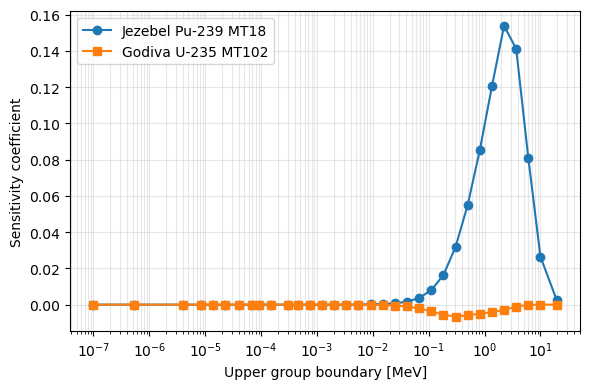

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(jezebel.group_structure[1:], pu239_fission_avg.reshape(-1), marker="o", label="Jezebel Pu-239 MT18")
ax.plot(godiva.group_structure[1:], u235_capture_avg.reshape(-1), marker="s", label="Godiva U-235 MT102")
ax.set_xscale("log")
ax.set_xlabel("Upper group boundary [MeV]")
ax.set_ylabel("Sensitivity coefficient")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

## Merge Serpent files

Multiple Serpent files can be merged when their energy grids match. The
`keep_last` policy is convenient for tutorials because it handles duplicate
response/material/ZA/MT entries deterministically.

In [7]:
merged = Sensitivity(list(serpent_files.values()), duplicate_policy="keep_last")

assert merged.reader == "serpent"
assert merged.n_groups == 33
assert "Pu-239" in merged.zais
assert "U-235" in merged.zais

avg_merged, rsd_merged = merged.get(resp="keff", mat="total", za="U-235", MT=18)
assert avg_merged.shape[-1] == merged.n_groups
print(f"Merged object: {merged.n_zai} nuclides, {merged.n_MTs} MTs, {merged.n_groups} groups")

Merged object: 8 nuclides, 55 MTs, 33 groups


## Collapse to a coarse grid

`collapse` mutates the object, so this example works on a copy.

In [8]:
godiva_fewG = copy.deepcopy(godiva)
idx = [0, 5, 11, 15, 22, 25, 33]
few_group = godiva_fewG.group_structure[idx]
godiva_fewG.collapse(fewgrp=few_group, egridname="tutorial-3G")

assert godiva_fewG.n_groups == len(idx) - 1
assert godiva_fewG.egridname == "tutorial-3G"
np.testing.assert_allclose(godiva_fewG.group_structure, few_group)
godiva_fewG.group_structure

u235_capture_fewG_avg, u235_capture_fewG_rsd = godiva_fewG.get(resp="keff", mat="total", za="U-235", MT=102)

# Plot multigroup profiles (without normalisation per unit lethargy)

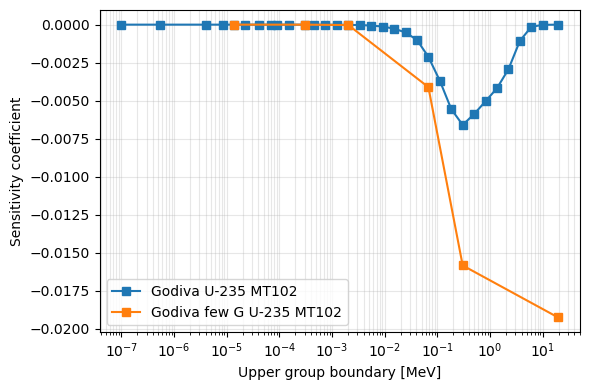

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(godiva.group_structure[1:], u235_capture_avg.reshape(-1), marker="s", label="Godiva U-235 MT102")
ax.plot(godiva_fewG.group_structure[1:], u235_capture_fewG_avg.reshape(-1), marker="s", label="Godiva few G U-235 MT102")

ax.set_xscale("log")
ax.set_xlabel("Upper group boundary [MeV]")
ax.set_ylabel("Sensitivity coefficient")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

# Normalise profiles per unit lethargy

In [10]:
sens_fewG = godiva_fewG.NormalizeSensProfile(u235_capture_fewG_avg.reshape(-1), godiva_fewG.group_structure)
sens_33G = godiva.NormalizeSensProfile(u235_capture_avg.reshape(-1), godiva.group_structure)

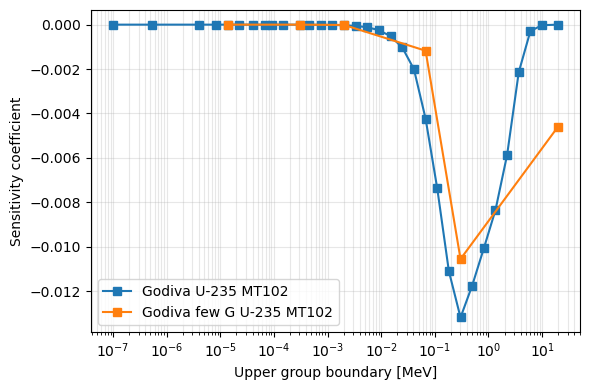

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(godiva.group_structure[1:], sens_33G, marker="s", label="Godiva U-235 MT102")
ax.plot(godiva_fewG.group_structure[1:], sens_fewG, marker="s", label="Godiva few G U-235 MT102")

ax.set_xscale("log")
ax.set_xlabel("Upper group boundary [MeV]")
ax.set_ylabel("Sensitivity coefficient")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()